# Video: Visualizing the Hypothesis Space for Linear Models

In this video, we will look at the hypothesis space for linear models and consider how to sample this space.

[![View on GitHub](https://img.shields.io/badge/GitHub-181717?logo=github&logoColor=white)](https://github.com/bu-cds-omds/dx601-examples/blob/main/week14/video_visualizing_the_hypothesis_space_for_linear_models.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bu-cds-omds/dx601-examples/blob/main/week14/video_visualizing_the_hypothesis_space_for_linear_models.ipynb)



Script: (faculty on screen)
* Let's take a look at the hypothesis space for linear models.

## Hypothesis Space for Linear (Affine) Models

Given input vectors $\mathbf{x} \in \mathbb{R}^d$,
* a linear model hypothesis: $h_\theta(\mathbf{x}) = \theta^\top \mathbf{x}$
* an affine model hypothesis: $h_{\theta,b}(\mathbf{x}) = \theta^\top \mathbf{x} + b$

For both, $\theta \in \mathbb{R}^d$ too.

Script:
* Given $d$-dimensional input vectors, the hypothesis space for linear models is $\mathbb{R}^d$, the space of $d$-tuples of real numbers.
* The hypothesis space for affine models is $\mathbb{R}^{d+1}$ with one more parameter for an additive constant.
* We will often casually treat these as the same thing, but technically speaking, if you want the additive constant, it needs to be an affine model or you need to add a dummy constant column.

## Hypothesis Space for 1 Input Affine Models

Given inputs $x \in \mathbb{R}$,
* $h_{\theta,b}(x) = \theta x + b$

So, the parameter space is two dimensional.

Script:
* If we consider a simple case with just one input value, then the affine model simplifies to $h(x)=\theta x + b$.
* So we have just two parameters in the hypothesis space.

## An Example Hypothesis


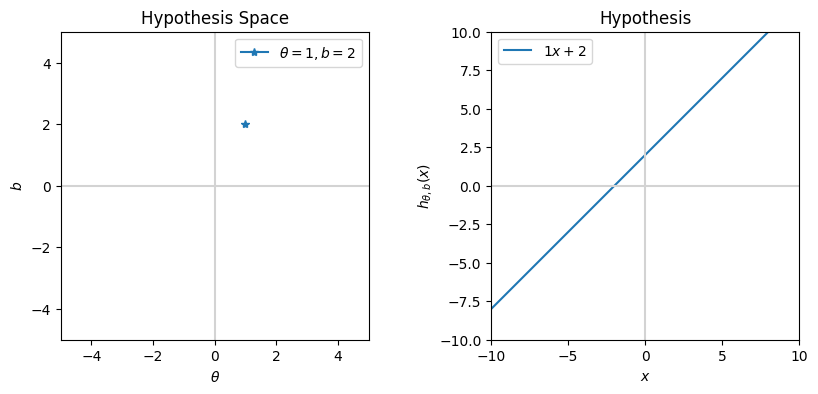

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 4))

theta = 1
b = 2

plt.subplot(1, 2, 1)
plt.plot(theta, b, label=f"$\\theta={theta}, b={b}$", marker="*")

plt.axvline(0, color="lightgrey")
plt.axhline(0, color="lightgrey")
plt.gca().set_aspect('equal')
plt.legend()
plt.title("Hypothesis Space")
plt.xlabel("$\\theta$")
plt.xlim(-5, 5)
plt.ylabel("$b$")
plt.ylim(-5, 5)

plt.subplot(1, 2, 2)
xs = np.linspace(-10, 10, 100)
plt.plot(xs, theta * xs + b, label=f"${theta}x + {b}$")

plt.axvline(0, color="lightgrey")
plt.axhline(0, color="lightgrey")
plt.gca().set_aspect('equal')
plt.legend()
plt.title("Hypothesis")
plt.xlabel("$x$")
plt.xlim(-10, 10)
plt.ylabel("$h_{\\theta,b}(x)$")
plt.ylim(-10, 10)

plt.subplots_adjust(wspace=0.25)
plt.show()

Script:
* Here's an example hypothesis with $\theta=1$ and $b=2$.
* We can increase $\theta$ to make the line steeper or decrease it to make the line flatter.
* Or we can increase $b$ to move the line up or decrease it to move it down.
* How can we visualize all the possibilities?
* A challenge here is that both parameters have an infinite range.
* Most parameter values will not even show up in the range of these charts.

## Sampling an Infinite Hypothesis Space


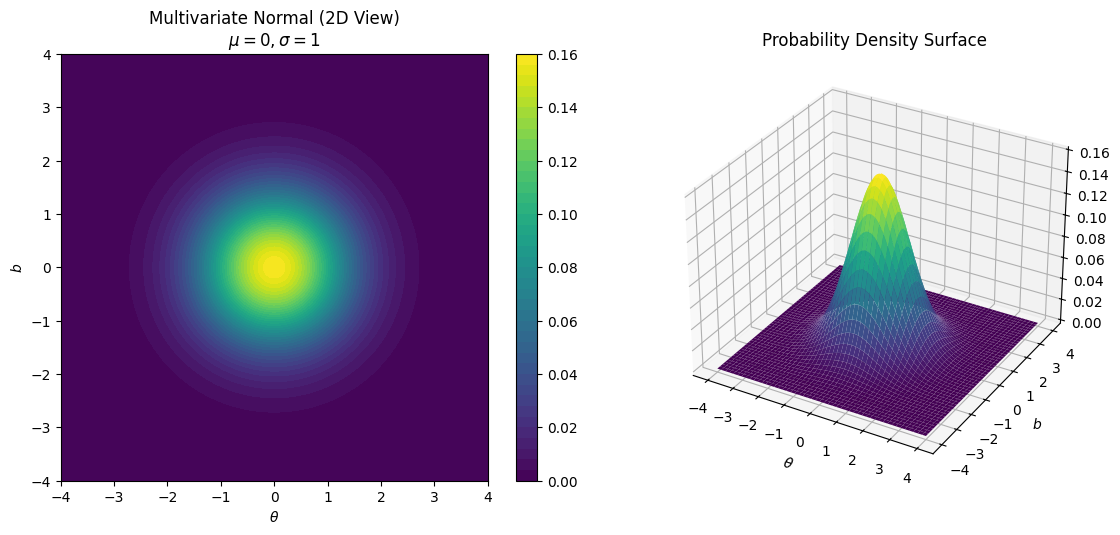

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Define the distribution parameters
mean = [0, 0]
cov = [[1, 0], [0, 1]]

# Increase resolution for a smoother plot
x = np.linspace(-4, 4, 500)
y = np.linspace(-4, 4, 500)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

# Calculate the probability density function (PDF)
rv = multivariate_normal(mean, cov)
Z = rv.pdf(pos)

# Plotting
fig = plt.figure(figsize=(12, 5))

# 2D Contour Plot
ax1 = fig.add_subplot(1, 2, 1)
contour = ax1.contourf(X, Y, Z, levels=50, cmap='viridis')
fig.colorbar(contour, ax=ax1)
ax1.set_title("Multivariate Normal (2D View)\n$\\mu=0, \\sigma=1$")
ax1.set_xlabel("$\\theta$")
ax1.set_ylabel("$b$")
ax1.set_aspect('equal')

# 3D Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', antialiased=True)
ax2.set_title("Probability Density Surface")
ax2.set_xlabel("$\\theta$")
ax2.set_ylabel("$b$")
ax2.set_zlabel("Density", labelpad=10)

# Adjust layout to prevent clipping of labels
plt.tight_layout()#rect=[0, 0, 0.95, 1])
plt.show()

Script:
*  The standard way to sample such a parameter space is to assume a prior distribution such as a multivariate normal distribution and sample that distribution.
* This assumption concentrates both the $\theta$ and $b$ parameters around zero.
* In theory, the whole parameter space is accessible with the multivariate normal distribution, but values far from zero will be rare.

## Script: Sampling the Hypothesis Space with a Prior


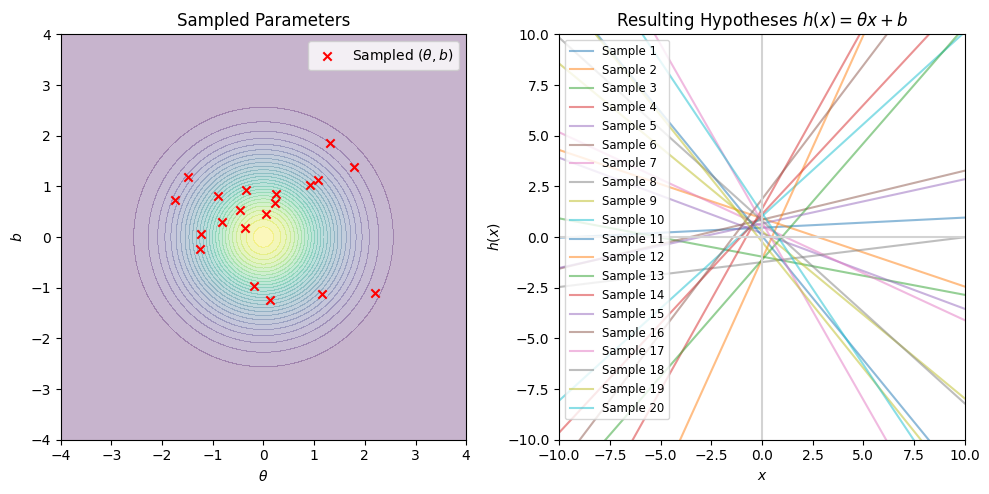

In [ ]:
# Number of samples to draw
n_samples = 20
samples = rv.rvs(n_samples)

plt.figure(figsize=(10, 5))

# Left: Parameter Space with sampled points
plt.subplot(1, 2, 1)
plt.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.3)
plt.scatter(samples[:, 0], samples[:, 1], color='red', marker='x', label='Sampled $(\\theta, b)$')

plt.gca().set_aspect('equal')
plt.title("Sampled Parameters")
plt.xlabel("$\\theta$")
plt.ylabel("$b$")
plt.legend()

# Right: Realized Hypotheses
plt.subplot(1, 2, 2)
xs = np.linspace(-10, 10, 100)
for i, (s_theta, s_b) in enumerate(samples):
    plt.plot(xs, s_theta * xs + s_b, alpha=0.5, label=f"Sample {i+1}")

plt.axhline(0, color="lightgrey")
plt.axvline(0, color="lightgrey")
plt.gca().set_aspect('equal')
plt.title("Resulting Hypotheses $h(x) = \\theta x + b$")
plt.xlabel("$x$")
plt.ylabel("$h(x)$")
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.legend(fontsize='small', loc='upper left')

plt.tight_layout()
plt.show()

Script:
* Let's look at some samples from this prior.
* On the left are some samples of $\theta$ and $b$ drawn from the multivariate distribution.
* Their values vary, but none of these twenty samples are very far from the mean at the origin.
* On the right are the resulting hypotheses.
* Let's look at a few more.

## Script: A Few More Samples...


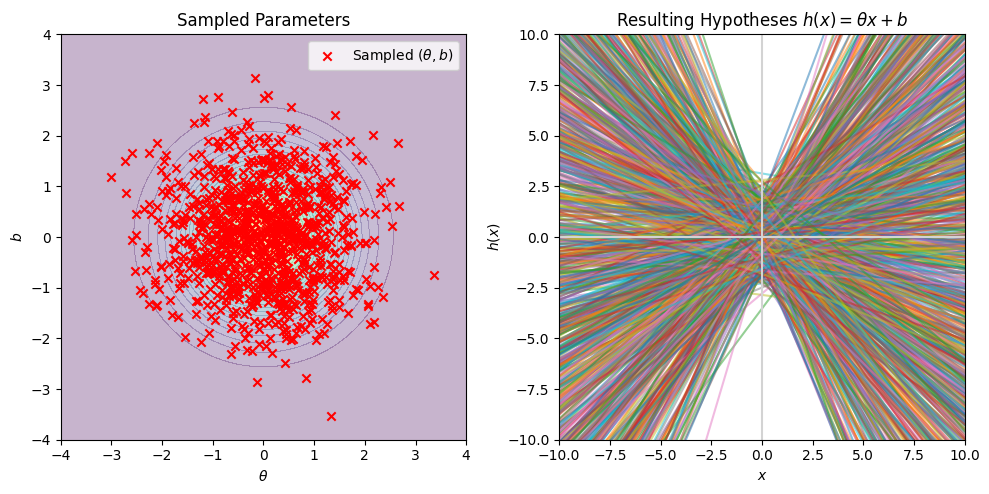

In [ ]:
# Number of samples to draw
n_samples = 1000
samples = rv.rvs(n_samples)

plt.figure(figsize=(10, 5))

# Left: Parameter Space with sampled points
plt.subplot(1, 2, 1)
plt.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.3)
plt.scatter(samples[:, 0], samples[:, 1], color='red', marker='x', label='Sampled $(\\theta, b)$')

plt.gca().set_aspect('equal')
plt.title("Sampled Parameters")
plt.xlabel("$\\theta$")
plt.ylabel("$b$")
plt.legend()

# Right: Realized Hypotheses
plt.subplot(1, 2, 2)
xs = np.linspace(-10, 10, 100)
for i, (s_theta, s_b) in enumerate(samples):
    plt.plot(xs, s_theta * xs + s_b, alpha=0.5)

plt.axhline(0, color="lightgrey")
plt.axvline(0, color="lightgrey")
plt.gca().set_aspect('equal')
plt.title("Resulting Hypotheses $h(x) = \\theta x + b$")
plt.xlabel("$x$")
plt.ylabel("$h(x)$")
plt.xlim(-10, 10)
plt.ylim(-10, 10)

plt.tight_layout()
plt.show()

Script:
* This multivariate normal distribution assumption appears to have severely constrained the sampled hypotheses.
* Look at those empty regions where none of the sampled hypotheses make predictions.
* This is not to say that there are no hypotheses making predictions there, but that they are unlikely with this prior.
* This is actually predictable if you think about how the prior interacts with predictions for $x=0$.

## Prior Distributions for Different Inputs

Recall:
* $h_{\theta,b}(x) = \theta x + b$
* $\theta \sim \mathcal{N}(0,1)$
* $b \sim \mathcal{N}(0,1)$

So:
* $h_{\theta,b}(0) = b \sim \mathcal{N}(0, 1)$
* $h_{\theta,b}(1) = \theta + b \sim \mathcal{N}(0, 2)$
* $h_{\theta,b}(-1) = -\theta + b \sim \mathcal{N}(0, 2)$

Script:
* Consider the distribution for input $x=0$.
* Given the formula for $h(x)$, $h(0)=b$.
* So, $h(0)$ has the same distribution as $b$ and follows a standard normal distribution.
* This is why it is rare for $h(0)$ to be more than 3 or less than -3.
* A similar analysis shows that both $h(1)$ and $h(-1)$ are normally distributed with twice the variance.
* This is why the prior limits the range of likely predictions.

## Linear Regression with Priors

With this multivariate normal prior,
* any hypothesis is still possible,
* large parameters are unlikely, but
* any parameters are possible with data to support them.

Script:
* Looking ahead, in your next machine learning class, you'll likely see these ideas in more depth.
* This prior distribution is used for Bayesian linear regression.
* Or, you may see it more subtlely as L2 regularization.
* Either way, the math is the same.
* The full parameter space is available, but there is a bias towards smaller parameter values and more slowly changing predictions.
* The result will be models that tend to generalize better.